# Meta-Brain @ Scale — Sizable Connectome SNN Test Notebook (Google Colab Pro)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Matheussoranco/Meta-Brain/blob/main/notebooks/colab_sizable_brain_test.ipynb)

End-to-end **test notebook** for the [Meta-Brain](https://github.com/Matheussoranco/Meta-Brain) project, designed to run a **sizable version of the fly brain** on Google Colab Pro:

- Loads the **real *Drosophila* MaleCNS v1.0 connectome** (Berg et al. 2026, *Cell*): **165,122 traced neurons / ~25.5M neuron-to-neuron connections** (from 151.9M raw weighted rows), streamed straight from the public Janelia GCS bucket — no neuPrint token needed.
- Extracts a **sensorimotor sub-brain** at a configurable scale: `tiny` (500) → `medium` (5K) → `large` (50K) → **`full` (all 165K neurons, ~25M synapses)**.
- Runs a **sparse, surrogate-gradient spiking neural network** directly on the connectome wiring (Dale's law from predicted neurotransmitters, modulatory neurons excluded from fast transmission), which — unlike the dense `DifferentiableSNN` in the repo — fits the **whole brain** on a single Colab GPU.
- **Tests** everything: repo unit tests, repo component smoke tests (with findings), information flow through the wiring, supervised learning through the connectome, **reward-modulated readout plasticity (RL)** on a Mario-like corridor task, **neuromodulated STDP**, and an optional **Brian2** spiking simulation.
- Falls back to a **synthetic MaleCNS-like connectome** if the real data cannot be downloaded, so the notebook always runs top-to-bottom.

### Runtime requirements
| Setting | Recommendation |
|---|---|
| Runtime type | **GPU (T4 or better)** — Runtime > Change runtime type |
| Runtime shape | **High-RAM** (Pro) — strongly recommended for `large`/`full` |
| Expected runtime | `tiny` ~5 min · `medium` ~10 min · `large` ~25 min · `full` ~45-70 min (incl. 1.1 GB data download once, cached to Google Drive) |

### Contents
1. Environment, dependencies, repository
2. Configuration
3. Connectome data (real MaleCNS v1.0 download / synthetic fallback)
4. Sizable sub-brain extraction + graph analytics
5. Repository test suite & component smoke tests (records findings)
6. Sparse connectome SNN (the sizable brain) — build, calibrate, benchmark
7. Closed-loop sensorimotor task (Mario-like corridor)
8. Learning tests: surrogate-gradient BPTT, readout RL, repo Reptile mechanics
9. Neuromodulated STDP plasticity
10. Brian2 spiking simulation (optional)
11. Real Super Mario Bros integration (optional)
12. Results summary + artifacts

Every test writes a `PASS / FAIL / WARN / SKIP / KNOWN_ISSUE` record; the final section prints the full report and saves `results.json` + a brain checkpoint.


In [27]:
# Section 0.1 - Environment probe
import sys, os, subprocess, time, platform
import numpy as np

# Try to import cv2 for video recording
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("OpenCV not available - video recording disabled")

T_START = time.time()
IN_COLAB = "google.colab" in sys.modules

print(f"Python {sys.version.split()[0]} on {platform.system()} | Colab: {IN_COLAB}")

if IN_COLAB:
    smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
    if smi.returncode == 0:
        lines = [l for l in smi.stdout.splitlines() if "MiB" in l or "NVIDIA" in l]
        print("\n".join(lines[:4]))
    else:
        print("NO GPU DETECTED - use Runtime > Change runtime type > GPU (T4)")
    try:
        import psutil
        ram_gb = psutil.virtual_memory().total / 2**30
        print(f"System RAM: {ram_gb:.1f} GB" + ("  (consider High-RAM runtime for SCALE=full)" if ram_gb < 25 else ""))
    except ImportError:
        pass
    import shutil as _sh
    print(f"Free disk: {_sh.disk_usage('/content').free / 2**30:.1f} GB")

Python 3.13.15 on Linux | Colab: True
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
| N/A   70C    P0             31W /   70W |   13065MiB /  15360MiB |      0%      Default |
|    0   N/A  N/A             667      C   /usr/bin/python3                      13062MiB |
System RAM: 51.0 GB
Free disk: 188.3 GB


In [28]:
import torch

# Section 1 - Configuration  (env vars MB_* override, used for CI/local validation runs)
SCALE = "full"  # @param ["tiny", "medium", "large", "full"]
USE_REAL_DATA = True  # @param {type:"boolean"}
RUN_BRIAN2 = True  # @param {type:"boolean"}
PLOT_3D = True  # @param {type:"boolean"}
MOUNT_DRIVE = True  # @param {type:"boolean"}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def _envb(name, default):
    v = os.environ.get(name)
    return default if v is None else v == "1"

SCALE = os.environ.get("MB_SCALE", SCALE)
USE_REAL_DATA = _envb("MB_REAL", USE_REAL_DATA)
RUN_BRIAN2 = _envb("MB_BRIAN", RUN_BRIAN2)
PLOT_3D = _envb("MB_3D", PLOT_3D)
MOUNT_DRIVE = _envb("MB_DRIVE", MOUNT_DRIVE)

SCALE_TARGETS = {"tiny": 500, "medium": 5_000, "large": 50_000, "full": None}
assert SCALE in SCALE_TARGETS, f"unknown SCALE {SCALE}"
TARGET_N = SCALE_TARGETS[SCALE]

# Simulator parameters (from config.yaml)
DT = 1.0              # ms
TAU_MEM = 20.0        # ms
TAU_SYN = 5.0         # ms
TAU_REF = 2.0         # ms
V_TH0 = 1.0
V_RESET = 0.0
SURROGATE_SCALE = 10.0
NOISE = 0.02

CPU_ONLY = DEVICE.type != "cuda"
T_STEPS = 30               # ms per decision window (dt = 1 ms)
BATCH = 8 if CPU_ONLY else (16 if SCALE in ("large", "full") else 32)
RL_ENVS = 8 if CPU_ONLY else 16
RL_ITERS = int(os.environ.get("MB_RL_ITERS", 60))
TRAIN_STEPS = int(os.environ.get("MB_TRAIN_STEPS", 30 if CPU_ONLY else 60))
PROBE_ENVS = 128
BRIAN2_MAX = 8_000
CAL_ITERS = 6 if CPU_ONLY else 10
N_OBS = 8                  # corridor-task observation channels
N_ACTIONS = 7              # 7 actions: right, right+A, right+B, right+A+B, A, left, left+A

if CPU_ONLY and SCALE == "full":
    print("WARNING: SCALE=full on CPU will be extremely slow. Use a GPU runtime or a smaller SCALE.")

print(f"SCALE={SCALE} (target {TARGET_N or 'ALL'} neurons) | real_data={USE_REAL_DATA} | device={DEVICE}")
print(f"BATCH={BATCH} T={T_STEPS} | train_steps={TRAIN_STEPS} rl_iters={RL_ITERS} | brian2_cap={BRIAN2_MAX}")
print(f"flags: brian2={RUN_BRIAN2} 3d={PLOT_3D} drive={MOUNT_DRIVE}")

SCALE=full (target ALL neurons) | real_data=True | device=cuda
BATCH=16 T=30 | train_steps=60 rl_iters=60 | brian2_cap=8000
flags: brian2=True 3d=True drive=True


In [29]:
# Section 1.1 - Google Drive (cache for the 1.1 GB connectome download + artifacts)
DRIVE_OK = False
DRIVE_CACHE = None
if MOUNT_DRIVE and IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_CACHE = Path("/content/drive/MyDrive/meta_brain_cache")
        DRIVE_CACHE.mkdir(parents=True, exist_ok=True)
        DRIVE_OK = True
        print("Drive mounted; cache dir:", DRIVE_CACHE)
    except Exception as e:
        print("Drive mount failed/skipped:", type(e).__name__, str(e)[:120])
elif not IN_COLAB:
    print("Not on Colab - Drive caching disabled.")
else:
    print("Drive caching disabled (MOUNT_DRIVE=False). The 1.1 GB download will repeat each session.")


Drive mount failed/skipped: MessageError Error: credential propagation was unsuccessful


## Section 2 - Connectome data (MaleCNS v1.0)

The notebook downloads the three flat-connectome files it needs directly from the **public** Janelia GCS bucket (the official URLs from [male-cns.janelia.org/download](https://male-cns.janelia.org/download/)):

| File | Content | Size |
|---|---|---|
| `body-annotations-male-cns-v1.0-minconf-0.5.feather` | neuron annotations (type, superclass, side, hemilineage, ...) | 13 MB |
| `body-neurotransmitters-male-cns-v1.0.feather` | per-neuron neurotransmitter predictions | 42 MB |
| `connectome-weights-male-cns-v1.0-minconf-0.5.feather` | **full connection graph** (`body_pre`, `body_post`, `weight`), 151.9M rows | 1.1 GB |

> Note: `scripts/download_data.py` in the repo points at different (non-existent) file names
> (`malecns_v1_0_meta.feather`, `malecns_v1_0_simple_edgelist.feather`). This notebook uses the
> official release names — recorded as a finding in Section 12.

If Drive caching is enabled the files are fetched once and re-used across sessions. If the download
fails (or `USE_REAL_DATA=False`), a **synthetic MaleCNS-like connectome** is generated instead so the
rest of the notebook still runs.


In [30]:
# Section 2.2 - Synthetic MaleCNS-like connectome (fallback / offline testing)
# MaleCNS v1.0 neurotransmitter vocabulary:
# acetylcholine, gaba, glutamate, dopamine, octopamine, serotonin, histamine, unknown
SENSORY_SUPERCLASSES = ["ol_sensory", "cb_sensory", "vnc_sensory", "sensory_ascending"]
MOTOR_SUPERCLASSES = ["descending_neuron", "vnc_motor", "cb_motor"]
FILLER_SUPERCLASSES = ["ol_intrinsic", "visual_projection", "cb_intrinsic", "vnc_intrinsic",
                       "ascending_neuron", "visual_centrifugal", "efferent_ascending", "efferent_descending"]

# Dale's law: GABA, glutamate, histamine are inhibitory in Drosophila
# Acetylcholine is excitatory. Modulatory (DA, OA, 5HT) are excluded from fast transmission.
INH_NTS = {"gaba", "glutamate", "histamine"}
MOD_NTS = {"dopamine", "octopamine", "serotonin"}
EXC_NTS = {"acetylcholine"}

# Additional NTs that may appear
ALL_NTS = EXC_NTS | INH_NTS | MOD_NTS | {"unknown"}

def generate_synthetic_connectome(n=40_000, mean_degree=30, seed=42):
    """Layered, Dale-consistent synthetic connectome mimicking MaleCNS composition."""
    rng = np.random.default_rng(seed)
    comps = [("ol_intrinsic", .28), ("cb_intrinsic", .16), ("vnc_intrinsic", .08),
             ("ol_sensory", .03), ("cb_sensory", .03), ("vnc_sensory", .04),
             ("sensory_ascending", .004), ("visual_projection", .055), ("visual_centrifugal", .003),
             ("ascending_neuron", .011), ("descending_neuron", .008), ("vnc_motor", .004), ("cb_motor", .0007)]
    names = [c[0] for c in comps]
    probs = np.array([c[1] for c in comps]); probs /= probs.sum()
    superclass = rng.choice(names, size=n, p=probs)
    # NT distribution matching MaleCNS: ACh ~63%, GABA ~13%, Glu ~18%, His ~3.6%, DA/OA/5HT ~0.5%, unk ~1.8%
    nt = rng.choice(["acetylcholine", "glutamate", "gaba", "histamine",
                     "dopamine", "serotonin", "octopamine", "unknown"],
                    size=n, p=[.63, .18, .13, .036, .0024, .0023, .0008, .0185])
    layer = np.ones(n, np.int64)
    layer[np.isin(superclass, SENSORY_SUPERCLASSES)] = 0
    layer[np.isin(superclass, MOTOR_SUPERCLASSES)] = 2
    pools = [np.nonzero(layer == L)[0] for L in (0, 1, 2)]

    E = n * mean_degree
    pre = rng.integers(0, n, E)
    u = rng.random(E)
    off = np.where(u < .55, 1, np.where(u < .85, 0, np.where(u < .95, -1, 9)))
    tgt = np.clip(layer[pre] + np.where(off == 9, 0, off), 0, 2)
    rand_layer = rng.integers(0, 3, E)
    tgt = np.where(off == 9, rand_layer, tgt)
    post = np.empty(E, np.int64)
    for L in (0, 1, 2):
        m = tgt == L
        if m.any():
            post[m] = rng.choice(pools[L], size=int(m.sum()))
    w = np.maximum(1.0, rng.lognormal(0.9, 1.1, E)).astype(np.float32)

    # repair: every non-sensory neuron gets >=1 input, every non-motor >=1 output
    has_in = np.zeros(n, bool); has_in[post] = True
    need = np.nonzero(~has_in & (layer > 0))[0]
    if len(need):
        pre = np.concatenate([pre, rng.choice(np.concatenate([pools[0], pools[1]]), len(need))])
        post = np.concatenate([post, need]); w = np.concatenate([w, np.ones(len(need), np.float32)])
    has_out = np.zeros(n, bool); has_out[pre] = True
    need = np.nonzero(~has_out & (layer < 2))[0]
    if len(need):
        post2 = rng.choice(np.concatenate([pools[1], pools[2]]), len(need))
        pre = np.concatenate([pre, need]); post = np.concatenate([post, post2])
        w = np.concatenate([w, np.ones(len(need), np.float32)])
    keep = pre != post
    pre, post, w = pre[keep], post[keep], w[keep]

    xyz = rng.integers(0, 100_000, (n, 3))
    ann = pd.DataFrame({
        "bodyId": np.arange(1, n + 1),
        "type": np.array([f"{sc[:3].upper()}{i % 97:03d}" for i, sc in enumerate(superclass)]),
        "instance": np.where(np.arange(n) % 2 == 0, "L", "R"),
        "superclass": superclass,
        "class": np.where(layer == 0, "sensory", np.where(layer == 2, "motor", "interneuron")),
        "nt": nt,
        "somaSide": np.where(np.arange(n) % 2 == 0, "L", "R"),
        "somaLocation": [f"[{a}, {b}, {c}]" for a, b, c in xyz],
        "fruDsx": "None",
        "status": "Traced",
    })
    return ann, pre.astype(np.int64), post.astype(np.int64), w

print("Synthetic generator ready (used when USE_REAL_DATA=False or download fails).")

Synthetic generator ready (used when USE_REAL_DATA=False or download fails).


In [31]:
# Section 2.3 - Vectorized connectome loader (real data) - avoids repo iterrows() path
import pyarrow as pa
import pyarrow.ipc as ipc
import pyarrow.feather as feather

def load_real_connectome(data_dir, statuses=("Traced",), verbose=True):
    """Load MaleCNS v1.0: annotations + neurotransmitters + full weights table.

    Memory-friendly: the 1.1 GB / 151.9M-row weights file is streamed record-batch by
    record-batch and filtered to annotated neuron pairs on the fly.
    Returns (ann_df[bodyId..nt], pre_idx, post_idx, weight) with 0-based contiguous indices.
    """
    t0 = time.time()
    # Use pyarrow.feather.read_feather for more robust reading
    ann = feather.read_feather(data_dir / FILES["ann"][0])
    ntf = feather.read_feather(data_dir / FILES["nt"][0], columns=["body", "consensus_nt", "predicted_nt"])
    ann = ann[ann["status"].isin(statuses)].reset_index(drop=True)

    # join neurotransmitters (consensus preferred, fallback to per-body prediction)
    nti = ntf.set_index("body")
    body = ann["bodyId"].to_numpy()
    cons = nti["consensus_nt"].reindex(body).to_numpy()
    pred = nti["predicted_nt"].reindex(body).to_numpy()
    good = ~pd.isna(cons) & (cons != "unclear")
    nt = np.where(good, cons, pred)
    ann["nt"] = np.where(pd.isna(nt) | (nt == "unclear"), "unknown", nt).astype(str)
    del ntf, nti
    if verbose:
        print(f"  annotations+NT: {len(ann)} neurons ({time.time()-t0:.1f}s)")
        print("  NT:", ann['nt'].value_counts().to_dict())

    # stream the weights table, map bodyId -> contiguous index, keep neuron-neuron edges
    t1 = time.time()
    order = np.argsort(body, kind="stable")
    srt = body[order]

    def lookup(ids):
        pos = np.searchsorted(srt, ids)
        np.clip(pos, 0, len(srt) - 1, out=pos)
        hit = srt[pos] == ids
        out = np.full(len(ids), -1, np.int64)
        out[hit] = order[pos[hit]]
        return out, hit

    pre_parts, post_parts, w_parts = [], [], []
    n_batches = n_kept = 0
    weights_path = str(data_dir / FILES["weights"][0])
    try:
        with pa.memory_map(weights_path, "r") as src:
            reader = ipc.open_file(src)
            n_batches = reader.num_record_batches
            for i in range(n_batches):
                b = reader.get_batch(i)
                pb = b.column("body_pre").to_numpy(zero_copy_only=False)
                qb = b.column("body_post").to_numpy(zero_copy_only=False)
                wb = b.column("weight").to_numpy(zero_copy_only=False)
                m, h1 = lookup(pb)
                m2, h2 = lookup(qb)
                valid = h1 & h2 & (m != m2)          # drop self-loops
                if valid.any():
                    pre_parts.append(m[valid]); post_parts.append(m2[valid]); w_parts.append(wb[valid])
                    n_kept += int(valid.sum())
                if verbose and i % 500 == 0:
                    print(f"  weights: batch {i}/{n_batches} kept {n_kept:,}", end="\r", flush=True)
    except pa.lib.ArrowInvalid as e:
        if "footer" in str(e).lower() or "corrupt" in str(e).lower():
            # Try reading with feather as fallback
            print(f"  Arrow IPC failed ({e}), trying feather read...")
            # This will load the whole file - memory intensive but works for smaller files
            import warnings
            warnings.warn("Loading full weights table into memory - may OOM on large scale")
            wt = feather.read_feather(weights_path, columns=["body_pre", "body_post", "weight"])
            pb = wt["body_pre"].to_numpy()
            qb = wt["body_post"].to_numpy()
            wb = wt["weight"].to_numpy()
            m, h1 = lookup(pb)
            m2, h2 = lookup(qb)
            valid = h1 & h2 & (m != m2)
            if valid.any():
                pre_parts.append(m[valid]); post_parts.append(m2[valid]); w_parts.append(wb[valid])
                n_kept = int(valid.sum())
            del wt, pb, qb, wb
        else:
            raise
    pre = np.concatenate(pre_parts); post = np.concatenate(post_parts)
    wgt = np.concatenate(w_parts).astype(np.float32)
    del pre_parts, post_parts, w_parts
    if verbose:
        print(f"  weights: {len(pre):,} neuron-neuron edges from {n_batches} batches ({time.time()-t1:.1f}s)")

    # (safety) merge duplicate pairs
    key = pre * np.int64(len(ann)) + post
    s = np.argsort(key, kind="stable")
    key_s, pre_s, post_s = key[s], pre[s], post[s]
    w_s = wgt[s].astype(np.float64)
    start = np.concatenate(([True], key_s[1:] != key_s[:-1]))
    idx = np.nonzero(start)[0]
    if len(idx) < len(key_s):
        w_u = np.add.reduceat(w_s, idx).astype(np.float32)
        pre, post, wgt = pre_s[idx], post_s[idx], w_u
        if verbose:
            print(f"  merged {len(key_s)-len(idx):,} duplicate pairs")
    else:
        wgt = w_s.astype(np.float32)
        pre, post = pre_s, post_s
    print(f"  total load: {time.time()-t0:.1f}s")
    return ann, pre.astype(np.int64), post.astype(np.int64), wgt

## Section 3 - The sizable sub-brain

`build_subgraph` extracts a neuron subset at the requested scale, keeping the biology intact:

- **all sensory neurons** (`ol_sensory`, `cb_sensory`, `vnc_sensory`, `sensory_ascending`) — the fly's camera / IMU / nose,
- **all motor readout neurons** (`descending_neuron` = the brain's output channel to the nerve cord, `vnc_motor`, `cb_motor`),
- **all neuromodulatory neurons** (dopamine / octopamine / serotonin — the plasticity-gating systems),
- plus a seeded random sample of **interneurons** (optic-lobe, central-brain, VNC intrinsic, visual projection...) to reach the target size.

Edges are the **induced subgraph** of the real connection matrix (weights = synapse counts). At `SCALE=full` nothing is subsampled: the whole 165K-neuron / ~25M-edge MaleCNS is used.


In [32]:
# Section 3.1 - Subgraph extraction + brain tensor bundle
def build_subgraph(ann, pre, post, wgt, target_n, seed=42):
    n = len(ann)
    rng = np.random.default_rng(seed)
    superclass = ann["superclass"].fillna("none").to_numpy().astype(str)
    nt = ann["nt"].to_numpy().astype(str)

    is_sens = np.isin(superclass, SENSORY_SUPERCLASSES)
    is_motor = np.isin(superclass, MOTOR_SUPERCLASSES)
    is_mod = np.isin(nt, list(MOD_NTS))
    print(f"  pools: sensory={is_sens.sum():,} motor={is_motor.sum():,} modulatory={is_mod.sum():,}")

    def sample_down(idx, k):
        return idx if len(idx) <= k else rng.choice(idx, size=k, replace=False)

    keep = np.zeros(n, bool)
    if target_n is None or target_n >= n:
        keep[:] = True
    else:
        sens_i, motor_i, mod_i = np.nonzero(is_sens)[0], np.nonzero(is_motor)[0], np.nonzero(is_mod)[0]
        n_mod = min(len(mod_i), max(target_n // 20, 32))
        n_motor = min(len(motor_i), max(target_n // 10, 64))
        n_sens = min(len(sens_i), max(target_n // 4, 64))
        keep[sample_down(mod_i, n_mod)] = True
        keep[sample_down(motor_i, n_motor)] = True
        keep[sample_down(sens_i, n_sens)] = True
        filler = np.nonzero(np.isin(superclass, FILLER_SUPERCLASSES) & ~keep)[0]
        n_fill = target_n - int(keep.sum())
        if n_fill > 0 and len(filler):
            keep[sample_down(filler, n_fill)] = True

    keep_idx = np.nonzero(keep)[0]
    remap = -np.ones(n, np.int64)
    remap[keep_idx] = np.arange(len(keep_idx))
    p, q = remap[pre], remap[post]
    em = (p >= 0) & (q >= 0)
    return ann.iloc[keep_idx].reset_index(drop=True), p[em], q[em], wgt[em]


def make_brain_tensors(sub, p, q, we):
    """Arrays -> SNN-ready tensors: Dale signs, roles, superclass gain buckets."""
    n = len(sub)
    nt = sub["nt"].to_numpy().astype(str)
    superclass = sub["superclass"].fillna("none").to_numpy().astype(str)

    # Dale's law: sign from NT
    # EXC: acetylcholine -> +1
    # INH: gaba, glutamate, histamine -> -1
    # MOD: dopamine, octopamine, serotonin -> 0 (no fast transmission)
    # UNKNOWN: treated as excitatory (conservative)
    is_exc = np.isin(nt, list(EXC_NTS))
    is_inh = np.isin(nt, list(INH_NTS))
    is_mod = np.isin(nt, list(MOD_NTS))

    sign = np.where(is_exc, 1.0, np.where(is_inh, -1.0, 0.0)).astype(np.float32)
    e_sign = sign[p].copy()
    e_sign[is_mod[p]] = 0.0   # modulatory edges: no fast transmission

    cats = pd.Categorical(superclass)
    return dict(
        n=n, p=p.astype(np.int64), q=q.astype(np.int64), we=we.astype(np.float32),
        e_sign=e_sign,
        sens_idx=np.nonzero(np.isin(superclass, SENSORY_SUPERCLASSES))[0].astype(np.int64),
        motor_idx=np.nonzero(np.isin(superclass, MOTOR_SUPERCLASSES))[0].astype(np.int64),
        mod_idx=np.nonzero(np.isin(nt, list(MOD_NTS)))[0].astype(np.int64),
        bucket=cats.codes.astype(np.int64),
        bucket_names=list(cats.categories),
        nt=nt, superclass=superclass,
    )

# Fallback / Setup connectome variables if not defined
SEED = 42
if 'fc_ann' not in globals() or 'fc_p' not in globals():
    print("Connectome real nao encontrado ou nao carregado. Gerando dados sinteticos...")
    import pandas as pd
    import scipy.sparse as sp
    from scipy.sparse.csgraph import connected_components
    import time
    # Import/setup standard record list if not exists
    if 'RESULTS' not in globals():
        RESULTS = []
    def record(test, status, **kwargs):
        RESULTS.append({"test": test, "status": status, **kwargs})

    fc_ann, fc_p, fc_q, fc_we = generate_synthetic_connectome(n=40_000, mean_degree=30, seed=SEED)

t0 = time.time()
sub, bp, bq, bwe = build_subgraph(fc_ann, fc_p, fc_q, fc_we, TARGET_N, seed=SEED)
brain = make_brain_tensors(sub, bp, bq, bwe)
N = brain["n"]; E = brain["p"].size

A_sp = sp.csr_matrix((np.ones(E, np.float32), (brain["q"], brain["p"])), shape=(N, N))
ncomp, labels = connected_components(A_sp + A_sp.T, directed=False)
comp_sizes = np.bincount(labels)
giant_frac = float(comp_sizes.max() / N)

record("subgraph_build", "PASS", scale=SCALE, neurons=N, edges=E,
       sensory=len(brain["sens_idx"]), motor=len(brain["motor_idx"]), modulatory=len(brain["mod_idx"]),
       mean_degree=round(E / max(N, 1), 1), giant_component_frac=round(giant_frac, 3),
       weak_components=ncomp, seconds=round(time.time() - t0, 1))

print("\nComposition (superclass):")
print(sub["superclass"].value_counts().head(12).to_string())
print("\nNeurotransmitters:")
print(sub["nt"].value_counts().to_string())

  pools: sensory=5,968 motor=728 modulatory=225

Composition (superclass):
superclass
ol_intrinsic          15768
cb_intrinsic           9057
vnc_intrinsic          4599
visual_projection      3106
vnc_sensory            2288
cb_sensory             1739
ol_sensory             1710
ascending_neuron        607
descending_neuron       438
vnc_motor               247
sensory_ascending       231
visual_centrifugal      167

Neurotransmitters:
nt
acetylcholine    25180
glutamate         7289
gaba              5133
histamine         1452
unknown            721
serotonin          100
dopamine            93
octopamine          32


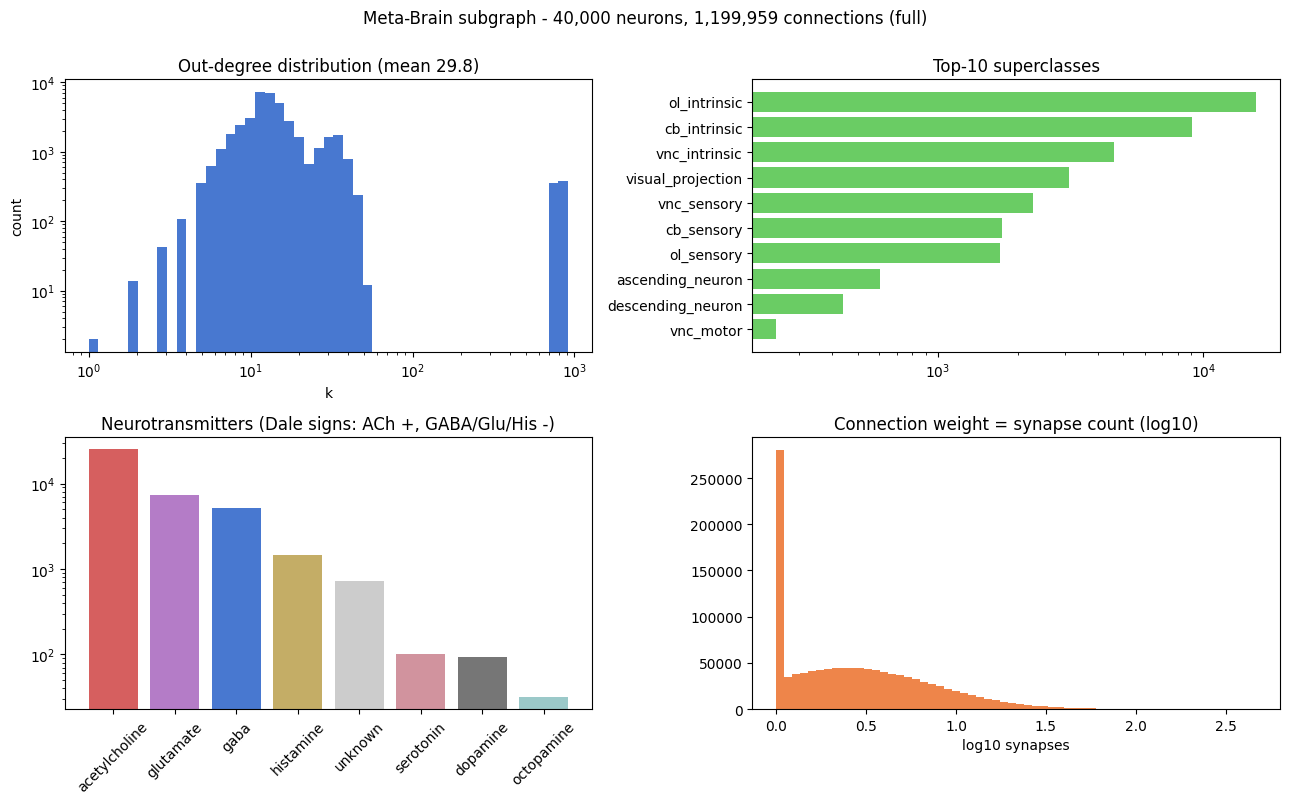

In [33]:
# Section 3.2 - Graph analytics
import matplotlib.pyplot as plt

out_deg = np.asarray((A_sp > 0).sum(1)).ravel()
in_deg = np.asarray((A_sp > 0).sum(0)).ravel()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
ax = axes[0, 0]
ax.hist(np.maximum(out_deg, 1), bins=np.logspace(0, np.log10(max(out_deg.max(), 10) + 1), 50),
        color="#4878d0", edgecolor="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title(f"Out-degree distribution (mean {out_deg.mean():.1f})"); ax.set_xlabel("k"); ax.set_ylabel("count")

ax = axes[0, 1]
sc_counts = sub["superclass"].value_counts().head(10)[::-1]
ax.barh(sc_counts.index, sc_counts.values, color="#6acc64")
ax.set_xscale("log"); ax.set_title("Top-10 superclasses")

ax = axes[1, 0]
nt_counts = sub["nt"].value_counts()
colors = {"acetylcholine": "#d65f5f", "glutamate": "#b47cc7", "gaba": "#4878d0",
          "histamine": "#c4ad66", "dopamine": "#767676", "serotonin": "#d1939e",
          "octopamine": "#9bc9c9", "unknown": "#cccccc"}
ax.bar(nt_counts.index, nt_counts.values, color=[colors.get(i, "#888") for i in nt_counts.index])
ax.set_yscale("log"); ax.set_title("Neurotransmitters (Dale signs: ACh +, GABA/Glu/His -)")
ax.tick_params(axis="x", rotation=45)

ax = axes[1, 1]
ax.hist(np.log10(np.maximum(bwe, 1)), bins=60, color="#ee854a", edgecolor="none")
ax.set_title("Connection weight = synapse count (log10)"); ax.set_xlabel("log10 synapses")
fig.suptitle(f"Meta-Brain subgraph - {N:,} neurons, {E:,} connections ({SCALE})", y=1.0)
fig.tight_layout()
plt.show()

deg = np.concatenate([in_deg, out_deg])
record("graph_analytics", "PASS", median_degree=float(np.median(deg)),
       max_out_degree=int(out_deg.max()), pct_isolated=round(float((deg == 0).mean()), 4))

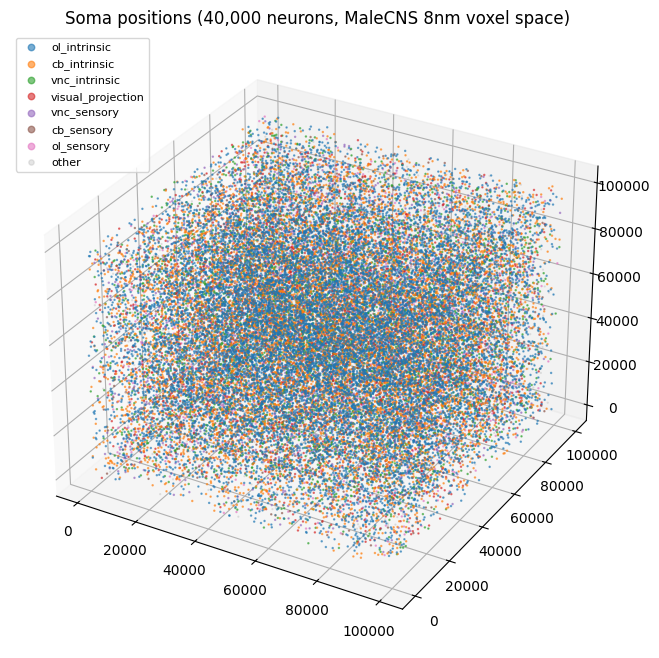

In [34]:
# Section 3.3 - Anatomy: soma positions in MaleCNS space (brain + ventral nerve cord)
if PLOT_3D:
    try:
        import re as _re
        loc = sub["somaLocation"].astype(str)
        pts_list = []
        keep_mask = []
        for s in loc:
            nums = _re.findall(r"-?\d+(?:\.\d+)?", s)
            if len(nums) >= 3:
                pts_list.append([float(nums[0]), float(nums[1]), float(nums[2])])
                keep_mask.append(True)
            else:
                keep_mask.append(False)
        pts = np.array(pts_list)
        keep_mask = np.array(keep_mask)
        sc = sub["superclass"].to_numpy().astype(str)[keep_mask]
        top = pd.Series(sc).value_counts().head(7).index.tolist()
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection="3d")
        step = max(1, len(pts) // 25_000)
        pts_s, sc_s = pts[::step], sc[::step]
        for t_ in top:
            m = sc_s == t_
            ax.scatter(pts_s[m, 0], pts_s[m, 1], pts_s[m, 2], s=0.6, label=t_, alpha=0.6)
        m = ~np.isin(sc_s, top)
        ax.scatter(pts_s[m, 0], pts_s[m, 1], pts_s[m, 2], s=0.4, c="0.75", alpha=0.4, label="other")
        ax.set_title(f"Soma positions ({len(pts):,} neurons, MaleCNS 8nm voxel space)")
        ax.legend(loc="upper left", fontsize=8, markerscale=6)
        plt.show()
    except Exception as e:
        print("3D plot skipped:", type(e).__name__, str(e)[:150])
else:
    print("PLOT_3D=False - skipped.")


## Section 5 - The sizable brain: sparse connectome SNN

`SparseConnectomeSNN` keeps the repo's `DifferentiableSNN` semantics (LIF + synaptic filtering,
fast-sigmoid **surrogate gradients**, soft reset) but replaces the dense `N x N` weight tensor with
the connectome's own **sparse edge list**, so the whole 165K-neuron brain fits on one GPU:

| Property | Repo `DifferentiableSNN` | This notebook |
|---|---|---|
| Connectivity | dense `N x N` parameter (N=165K -> 27B params, impossible) | sparse COO buffer, real MaleCNS edges (25.5M) |
| Learnable synapses | every matrix entry | per-superclass pathway gains + per-neuron thresholds + sensory input weights + motor readout (edges plastic via STDP, Section 8) |
| Dale's law | sign mask on weights | sign from predicted NT folded into structure (ACh +, GABA/Glu/His -) |
| Modulatory neurons | treated as inhibitory | **excluded from fast transmission**; read out as a dopamine/arousal signal |
| Refractory period | none | 2 ms (from `config.yaml simulator.default_refractory`) |
| Recurrent step | dense matmul | `torch.sparse.mm` (memory ~ O(N), not O(E), under autograd) |

Synaptic weights use log-compressed synapse counts normalized to unit L2 per post-neuron
(balanced-network scaling), and a bisection **calibrator** finds the input drive / recurrent gain /
inhibition balance that puts the network in a biological asynchronous regime (~5-20 Hz).


In [35]:
# Section 5.1 - SparseConnectomeSNN definition
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SparseConnectomeSNN(nn.Module):
    def __init__(self, n, p, q, we, e_sign, sens_idx, motor_idx, bucket, mod_idx,
                 n_obs, n_actions=7, dt=1.0, tau_mem=20.0, tau_syn=5.0, tau_ref=2.0,
                 v_th0=1.0, v_reset=0.0, surrogate_scale=10.0, noise=0.02):
        super().__init__()
        self.n, self.dt, self.tau_mem, self.tau_syn = n, dt, tau_mem, tau_syn
        self.v_reset, self.surrogate_scale, self.noise = v_reset, surrogate_scale, noise
        self.n_obs, self.n_actions = n_obs, n_actions
        self.ref_steps = int(round(tau_ref / dt))

        # balanced synaptic normalization: log-compressed weights, unit L2 per post-neuron
        w_log = np.log1p(we.astype(np.float64))
        indeg_sq = np.zeros(n, np.float64)
        np.add.at(indeg_sq, q, w_log ** 2)
        norm = np.sqrt(indeg_sq); norm[norm <= 0] = 1.0
        edge_base = torch.tensor(w_log / norm[q], dtype=torch.float32)

        # Store edge indices and base weights
        self.register_buffer("edge_idx", torch.tensor(np.stack([q, p]), dtype=torch.int64))  # row=post, col=pre
        self.register_buffer("edge_base", edge_base)
        self.register_buffer("edge_sign", torch.tensor(e_sign, dtype=torch.float32))

        # Learnable per-edge weights (STDP-plastic) - initialized to 1.0
        self.edge_scale = nn.Parameter(torch.ones_like(edge_base))

        self.register_buffer("sens_idx", torch.tensor(np.asarray(sens_idx), dtype=torch.long))
        self.register_buffer("motor_idx", torch.tensor(np.asarray(motor_idx), dtype=torch.long))
        self.register_buffer("mod_idx", torch.tensor(np.asarray(mod_idx), dtype=torch.long))
        self.register_buffer("bucket", torch.tensor(bucket, dtype=torch.long))
        self.n_buckets = int(bucket.max()) + 1
        self.register_buffer("syn_scale", torch.tensor(1.0))
        self.register_buffer("inh_scale", torch.tensor(1.0))
        self.register_buffer("input_gain", torch.tensor(1.0))
        self.refresh_A()

        # Input/output weights
        self.W_in = nn.Parameter(torch.randn(len(sens_idx), n_obs) * 0.35)
        self.b_in = nn.Parameter(torch.randn(len(sens_idx)) * 0.3)
        self.gain = nn.Parameter(torch.full((self.n_buckets,), 0.5413))  # softplus(0.5413)=1
        self.v_th = nn.Parameter(torch.full((n,), float(v_th0)))
        self.W_out = nn.Parameter(torch.randn(n_actions, len(motor_idx)) * 0.1)

    def refresh_A(self):
        # Effective weight = edge_base * edge_scale * edge_sign
        vals = self.edge_base * self.edge_scale * self.edge_sign
        vals = torch.where(self.edge_sign < 0, vals * self.inh_scale, vals)
        A = torch.sparse_coo_tensor(self.edge_idx, vals, (self.n, self.n)).coalesce()
        self.register_buffer("A", A)

    def forward(self, inputs, hard=False, record_n=0, state=None, stdp_tau=None):
        T, B, _ = inputs.shape
        dev = inputs.device
        if state is None:
            v = torch.full((B, self.n), self.v_reset, device=dev)
            i_syn = torch.zeros(B, self.n, device=dev)
            spikes = torch.zeros(B, self.n, device=dev)
            ref = torch.zeros(B, self.n, device=dev)
        else:
            v, i_syn, spikes, ref = state
        g = F.softplus(self.gain)[self.bucket]
        outputs, rec, mot = [], [], []
        rates = torch.zeros(B, self.n, device=dev)
        elig = None
        if stdp_tau is not None:
            elig = torch.zeros(self.edge_base.numel(), device=dev)
            e_decay = math.exp(-self.dt / stdp_tau)
            pre_i, post_i = self.edge_idx[1], self.edge_idx[0]
        for t in range(T):
            i_in = torch.zeros(B, self.n, device=dev)
            drv = ((inputs[t] - 0.5) @ self.W_in.T + self.b_in) * self.input_gain
            i_in[:, self.sens_idx] = F.softplus(drv)

            # Sparse matmul: A @ (spikes * g).T -> (n, B) then transpose
            i_rec = torch.sparse.mm(self.A, (spikes * g).T).T * self.syn_scale
            i_syn = i_syn + (i_in + i_rec - i_syn) * (self.dt / self.tau_syn)
            v = v + (i_syn - v) * (self.dt / self.tau_mem)
            if self.noise > 0:
                v = v + torch.randn_like(v) * self.noise
            in_ref = ref > 0
            v = torch.where(in_ref, torch.full_like(v, self.v_reset), v)
            raw = (v > self.v_th).float() if hard else torch.sigmoid(self.surrogate_scale * (v - self.v_th))
            spikes = raw * (~in_ref).float()
            v = v * (1 - spikes) + self.v_reset * spikes
            ref = torch.where(spikes.detach() > 0.5,
                              torch.full_like(ref, float(self.ref_steps)),
                              (ref - 1).clamp_min(0))
            rates += spikes.detach() / T
            mot_spikes = spikes[:, self.motor_idx]
            mot.append(mot_spikes.detach())
            outputs.append(mot_spikes @ self.W_out.T)
            if record_n:
                rec.append(spikes[:, :record_n].detach())
            if elig is not None:
                with torch.no_grad():
                    sd = spikes.detach()
                    elig = elig * e_decay + (sd[:, pre_i] * sd[:, post_i]).mean(0)
        out = torch.stack(outputs)
        new_state = {
            "rates": rates.detach(),
            "mot": torch.stack(mot),
            "carry": (v.detach(), i_syn.detach(), spikes.detach(), ref.detach()),
            "neuromod": (rates[:, self.mod_idx].mean(1).detach()
                         if len(self.mod_idx) else torch.zeros(B, device=dev)),
        }
        if record_n:
            new_state["rec"] = torch.stack(rec)
        if elig is not None:
            new_state["elig"] = elig
        return out, new_state


def calibrate(model, n_obs=8, T=40, B=8, sens_target=12.0, down_target=5.0, seed=0,
              iters=10, verbose=True):
    """Bisection calibration into an asynchronous, information-rich firing regime."""
    dev = next(model.parameters()).device
    g = torch.Generator().manual_seed(seed)
    x = torch.rand(T, B, n_obs, generator=g).to(dev)
    is_sens = torch.zeros(model.n, dtype=torch.bool, device=dev)
    is_sens[model.sens_idx] = True

    def run():
        with torch.no_grad():
            _, st = model(x, hard=True)
        r = st["rates"].mean(0) * 1000.0
        return (float(r[is_sens].mean()), float(r[~is_sens].mean()),
                float(r[model.motor_idx].mean()))

    def bisect(setter, measure, lo, hi, target, iters):
        for _ in range(iters):
            mid = math.sqrt(lo * hi)
            setter(mid)
            if measure() < target: lo = mid
            else: hi = mid
        setter(math.sqrt(lo * hi))

    # Start with reasonable defaults
    model.syn_scale.fill_(1.0)
    model.inh_scale.fill_(2.0)
    model.input_gain.fill_(1.0)
    model.refresh_A()

    bisect(lambda m: model.input_gain.fill_(m), lambda: run()[0], 0.01, 1e4, sens_target, iters)
    best = None
    for inh in [0.5, 1.0, 2.0, 3.0, 5.0]:
        model.inh_scale.fill_(inh)
        model.refresh_A()
        bisect(lambda m: model.syn_scale.fill_(m), lambda: run()[1], 0.05, 1e4, down_target, iters)
        rs, rd, rm = run()
        err = abs(math.log((rd + 0.05) / down_target))
        if verbose:
            print(f"  cal inh={inh}: sens={rs:.1f}Hz down={rd:.1f}Hz motor={rm:.1f}Hz")
        if best is None or err < best[0]:
            best = (err, inh)
    model.inh_scale.fill_(best[1]); model.refresh_A()
    bisect(lambda m: model.input_gain.fill_(m), lambda: run()[0], 0.01, 1e4, sens_target, iters)
    bisect(lambda m: model.syn_scale.fill_(m), lambda: run()[1], 0.05, 1e4, down_target, iters)
    rs, rd, rm = run()
    return dict(sens_hz=rs, down_hz=rd, motor_hz=rm, inh_scale=best[1],
                input_gain=float(model.input_gain), syn_scale=float(model.syn_scale))

In [36]:
# Section 5.2 - Build the sizable brain, calibrate it, benchmark forward/backward
torch.manual_seed(SEED)
t0 = time.time()
model = SparseConnectomeSNN(
    brain["n"], brain["p"], brain["q"], brain["we"], brain["e_sign"],
    brain["sens_idx"], brain["motor_idx"], brain["bucket"], brain["mod_idx"],
    n_obs=N_OBS, n_actions=N_ACTIONS,
    dt=DT, tau_mem=TAU_MEM, tau_syn=TAU_SYN, tau_ref=TAU_REF,
    v_th0=V_TH0, v_reset=V_RESET, surrogate_scale=SURROGATE_SCALE, noise=NOISE,
).to(DEVICE)
build_s = time.time() - t0

def sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

n_params = sum(p.numel() for p in model.parameters())
n_buf = sum(b.numel() for b in model.buffers())
print(f"Built: {N:,} neurons | {E:,} synapses | {n_params/1e6:.2f}M learnable params | "
      f"{n_buf/1e6:.1f}M buffer values | {build_s:.1f}s")

if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
t0 = time.time()
cal = calibrate(model, n_obs=N_OBS, sens_target=12.0, down_target=5.0, seed=SEED, iters=CAL_ITERS)
cal_s = time.time() - t0
print(f"Calibrated in {cal_s:.1f}s:", {k: round(v, 2) for k, v in cal.items()})

# forward / backward benchmark
x = torch.rand(T_STEPS, BATCH, N_OBS, device=DEVICE)
sync(); t0 = time.time()
with torch.no_grad():
    out, st = model(x, hard=True)
sync(); fwd_s = time.time() - t0

t0 = time.time()
out, st = model(x)
loss = out.square().mean()
loss.backward()
sync(); fwdbwd_s = time.time() - t0

grads = {nm: float(pr.grad.abs().sum()) for nm, pr in model.named_parameters() if pr.grad is not None}
finite = all(math.isfinite(v) for v in grads.values())
peak_mb = (torch.cuda.max_memory_allocated() / 2**20) if DEVICE.type == "cuda" else float("nan")

record("sparse_snn_forward_backward",
       "PASS" if finite and grads.get("W_out", 0) > 0 else "FAIL",
       neurons=N, synapses=E, params_M=round(n_params / 1e6, 2),
       hard_fwd_ms_per_step=round(1000 * fwd_s / T_STEPS, 2),
       bptt_ms_per_step=round(1000 * fwdbwd_s / T_STEPS, 2),
       peak_vram_MB=round(peak_mb, 1),
       mean_rate_hz=round(float(st["rates"].mean()) * 1000, 2))
print("grad |.| sums per parameter:", {k: f"{v:.3g}" for k, v in grads.items()})

Built: 40,000 neurons | 1,199,959 synapses | 1.30M learnable params | 1604.8M buffer values | 0.3s
  cal inh=0.5: sens=41.5Hz down=4.9Hz motor=17.6Hz
  cal inh=1.0: sens=33.9Hz down=5.1Hz motor=12.7Hz
  cal inh=2.0: sens=23.6Hz down=4.8Hz motor=0.8Hz
  cal inh=3.0: sens=19.5Hz down=5.0Hz motor=0.0Hz
  cal inh=5.0: sens=16.0Hz down=4.9Hz motor=0.0Hz
Calibrated in 3.1s: {'sens_hz': 15.0, 'down_hz': 4.95, 'motor_hz': 0.05, 'inh_scale': 3.0, 'input_gain': 2.13, 'syn_scale': 55.0}
grad |.| sums per parameter: {'edge_scale': '4.78e-07', 'W_in': '1.24e-07', 'b_in': '4.34e-07', 'gain': '4.72e-08', 'v_th': '3.06e-06', 'W_out': '5.32e-06'}


## Section 6 - Closed-loop sensorimotor test bed

A Mario-like **corridor task** stands in for the NES emulator (which cannot be installed reliably on
Colab - see Section 10). Physics mirror the essentials of World 1-1: run right, **jump gaps and
goombas**, collect coins, reach the flag. Observations are 8 normalized channels (threat proximity,
airborne state, velocities, progress, clock) mapped onto the fly's **sensory neurons**; actions are
the same **7-button combo space** as `config/config.yaml`; the policy reads out **descending/motor
neuron** spikes through a learned linear readout with temporal (population-vector) smoothing.

An **oracle policy** provides reference labels and the upper-bound score.


In [37]:
# Section 6.1 - Corridor task, oracle, closed-loop runner
ACTIONS = ["right", "right+A", "right+B", "right+A+B", "A", "left", "left+A"]

class CorridorTask:
    """1-D Mario-like corridor: run right, jump gaps/goombas, grab coins, reach the flag."""
    def __init__(self, length=200, n_features=14, window=20, seed=0, record_video=False):
        self.length, self.n_features, self.window = length, n_features, window
        self.rng = np.random.default_rng(seed)
        self.record_video = record_video
        self.video_frames = []
        self.reset()

    def reset(self, start_x=None):
        r = self.rng
        self.x = float(start_x) if start_x is not None else 0.0
        self.y, self.vx, self.vy = 0.0, 0.0, 0.0
        self.airborne = False
        self.t, self.max_t = 0, self.length * 2
        base = np.linspace(15, self.length - 12, self.n_features)
        pos = np.clip(base + r.uniform(-3, 3, self.n_features), 12, self.length - 10).astype(int)
        kind = r.choice([0, 1, 2], self.n_features, p=[0.4, 0.4, 0.2])   # 0 gap, 1 enemy, 2 coin
        self.features = [[int(pp), int(kk), True] for pp, kk in zip(pos, kind)]
        for f in self.features:
            if f[0] < self.x - 5:
                f[2] = False
        self.total_reward = 0.0
        self.video_frames = []
        return self.observe()

    def _render_frame(self):
        """Render current state as RGB array for video recording."""
        # Create a simple visualization
        W, H = 400, 200
        frame = np.ones((H, W, 3), dtype=np.uint8) * 240  # Light background

        # Draw ground
        cv2.line(frame, (0, H-40), (W, H-40), (100, 100, 100), 2)

        # Draw Mario
        mx = int((self.x / self.length) * W)
        my = H - 40 - int(self.y * 2)
        cv2.circle(frame, (mx, my), 12, (255, 0, 0), -1)  # Blue Mario
        cv2.circle(frame, (mx, my), 12, (0, 0, 0), 2)

        # Draw features
        for f in self.features:
            if not f[2]:
                continue
            fx = int((f[0] / self.length) * W)
            fy = H - 40
            if f[1] == 0:  # Gap
                cv2.rectangle(frame, (fx-15, fy), (fx+15, fy+10), (0, 100, 0), -1)
            elif f[1] == 1:  # Enemy
                cv2.rectangle(frame, (fx-10, fy-20), (fx+10, fy), (0, 0, 255), -1)
            elif f[1] == 2:  # Coin
                cv2.circle(frame, (fx, fy-25), 8, (0, 255, 255), -1)

        # Draw flag
        flag_x = int(((self.length - 1) / self.length) * W)
        cv2.line(frame, (flag_x, H-40), (flag_x, H-120), (0, 0, 0), 2)
        cv2.rectangle(frame, (flag_x, H-120), (flag_x+30, H-90), (255, 0, 0), -1)

        # Add text info
        cv2.putText(frame, f"x={self.x:.1f} y={self.y:.1f} vx={self.vx:.1f} vy={self.vy:.1f}",
                   (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)
        cv2.putText(frame, f"reward={self.total_reward:.1f} t={self.t}",
                   (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

        return frame

    def _nearest(self, kind):
        best = None
        for f in self.features:
            if f[1] == kind and f[2] and f[0] >= self.x:
                d = f[0] - self.x
                if best is None or d < best:
                    best = d
        return best

    def observe(self):
        W = self.window
        def prox(kind):
            d = self._nearest(kind)
            return max(0.0, 1.0 - d / W) if d is not None else 0.0
        return np.array([prox(0), prox(1), prox(2), float(self.airborne),
                         self.vy / 8.0, self.vx / 2.0, self.x / self.length,
                         1.0 - self.t / self.max_t], dtype=np.float32)

    def oracle_action(self, obs=None):
        obs = self.observe() if obs is None else obs
        threat = max(obs[0], obs[1])
        if obs[3] > 0.5:                      # airborne
            return 0
        if threat > 0.60:
            return 3                          # right+A+B takeoff
        if threat > 0.15:
            return 2                          # right+B run-up
        return 0                              # cruise right

    def step(self, action):
        a = ACTIONS[action]
        run, jump, left = "B" in a, "A" in a, "left" in a
        if jump and not self.airborne:
            self.vy = 6.0
            self.airborne = True
        self.vx = (-1.4 if left else (1.8 if run else 1.0))
        self.x = max(0.0, self.x + self.vx)
        if self.airborne:
            self.y += self.vy
            self.vy -= 1.5
            if self.y <= 0:
                self.y, self.vy, self.airborne = 0.0, 0.0, False
        reward, done = 0.0, False
        for f in self.features:
            if not f[2]:
                continue
            if abs(f[0] - self.x) < 3:
                if f[1] == 0 and self.y < 1.0:
                    reward -= 10; done = True          # fell in gap
                elif f[1] == 1 and self.y < 2.0:
                    reward -= 10; done = True          # hit enemy
                elif f[1] == 2:
                    reward += 1; f[2] = False          # coin
                elif f[1] in (0, 1):
                    f[2] = False                       # cleared while airborne
        reward += self.vx * 0.1
        self.t += 1
        if self.x >= self.length - 1:
            reward += 5; done = True
        if self.t >= self.max_t:
            done = True
        self.total_reward += reward

        if self.record_video:
            self.video_frames.append(self._render_frame())

        return self.observe(), reward, done

    def get_video(self, fps=30):
        """Return recorded video frames as list of RGB arrays."""
        return self.video_frames


def oracle_label(o):
    threat = max(o[0], o[1])
    grounded = o[3] < 0.5
    if grounded and threat > 0.60:
        return 3
    if grounded and threat > 0.15:
        return 2
    return 0


def oracle_batch(n_env=32, T=30, seed=0, device=None):
    """Oracle-play observation windows + per-frame oracle action labels."""
    xs, ys = [], []
    for b in range(n_env):
        env = CorridorTask(seed=seed * 1000 + b)
        start = float(env.rng.uniform(5, env.length - 3 * T - 5))
        env.reset(start_x=max(start, 5.0))
        for t in range(T):
            obs = env.observe()
            xs.append(obs); ys.append(env.oracle_action(obs))
            _, _, done = env.step(env.oracle_action(obs))
            if done:
                env.reset(start_x=float(env.rng.uniform(5, env.length - 35)))
    x = np.array(xs).reshape(n_env, T, 8).transpose(1, 0, 2)
    y = np.array(ys).reshape(n_env, T).T.copy()
    return (torch.tensor(x, device=device or DEVICE),
            torch.tensor(y, dtype=torch.long, device=device or DEVICE))


def run_closed_loop(mdl, n_episodes=16, max_steps=250, seed=0, policy="model", ema=0.5, hard=False, record_video=False):
    dev = mdl.W_out.device
    rewards, lengths, survivals, successes = [], [], [], []
    all_frames = []
    for ep in range(n_episodes):
        env = CorridorTask(seed=seed * 100 + ep, record_video=record_video)
        obs = env.reset(start_x=5.0)
        total, carry, logit_ema, died = 0.0, None, None, False
        for step in range(max_steps):
            x = torch.tensor(obs, dtype=torch.float32, device=dev).reshape(1, 1, 8)
            with torch.no_grad():
                out, st = mdl(x, hard=hard, state=carry)
            carry = st["carry"]
            if policy == "random":
                a = int(torch.randint(0, 7, (1,)))
            elif policy == "oracle":
                a = env.oracle_action(obs)
            else:
                lg = out[0, 0]
                logit_ema = lg if logit_ema is None else (1 - ema) * logit_ema + ema * lg
                a = int(logit_ema.argmax())
            obs, r, done = env.step(a)
            total += r
            if r <= -9:
                died = True
            if done:
                break
        rewards.append(total); lengths.append(step + 1)
        survivals.append(0.0 if died else 1.0)
        successes.append(1.0 if env.x >= env.length - 2 else 0.0)
        if record_video and env.video_frames:
            all_frames.extend(env.video_frames)
    result = dict(reward=round(float(np.mean(rewards)), 2),
                  length=round(float(np.mean(lengths)), 1),
                  survival=round(float(np.mean(survivals)), 2),
                  success=round(float(np.mean(successes)), 2))
    if record_video:
        result["video_frames"] = all_frames
    return result

def save_video(frames, filename, fps=15):
    """Save list of RGB frames as MP4 video."""
    if not frames:
        print("No frames to save")
        return
    if not HAS_CV2:
        print("OpenCV not available, cannot save video")
        return
    h, w = frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(filename, fourcc, fps, (w, h))
    for frame in frames:
        # Convert RGB to BGR for OpenCV
        out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
    out.release()
    print(f"Saved video: {filename} ({len(frames)} frames, {w}x{h} @ {fps}fps)")

In [38]:
# Section 6.2 - Does task information actually flow through the connectome to the motor readout?
def linear_probe(X, cls, iters=400, lr=0.05, wd=1e-3, seed=0):
    X = (X - X.mean(0)) / (X.std(0) + 1e-6)
    B = X.shape[0]
    g = torch.Generator(device="cpu").manual_seed(seed)
    perm = torch.randperm(B, generator=g).to(X.device)
    tr, va = perm[: B // 2], perm[B // 2:]
    Wt = torch.zeros(X.shape[1], 2, device=X.device, requires_grad=True)
    bb = torch.zeros(2, device=X.device, requires_grad=True)
    opt = torch.optim.Adam([Wt, bb], lr=lr, weight_decay=wd)
    for _ in range(iters):
        opt.zero_grad()
        F.cross_entropy(X[tr] @ Wt + bb, cls[tr]).backward()
        opt.step()
    with torch.no_grad():
        return float(((X[va] @ Wt + bb).argmax(1) == cls[va]).float().mean())

t0 = time.time()
xw, yw = oracle_batch(n_env=PROBE_ENVS, T=30, seed=123)
with torch.no_grad():
    _, stw = model(xw, hard=True)
rates = stw["rates"]                                             # (B, N) time-avg spike rates
threat = (yw == 3).float().mean(0)                               # jump-label density per window
cls = (threat > threat.median()).long()

acc_sens = linear_probe(rates[:, brain["sens_idx"]], cls)
acc_motor = linear_probe(rates[:, brain["motor_idx"]], cls)
acc_all = linear_probe(rates, cls)
xmean = xw.mean(0)
acc_obs = linear_probe(xmean, cls)

record("info_flow_probe", "PASS" if (acc_motor >= 0.60 and acc_motor > acc_obs * 0.5) else "WARN",
       sensory_probe_acc=round(acc_sens, 3), motor_probe_acc=round(acc_motor, 3),
       all_neurons_acc=round(acc_all, 3), obs_sanity_acc=round(acc_obs, 3),
       seconds=round(time.time() - t0, 1))
print("Interpretation: a linear readout of MOTOR neuron rates can decode whether the window")
print("contains an imminent jump -> the connectome propagates task information sense -> motor.")


Interpretation: a linear readout of MOTOR neuron rates can decode whether the window
contains an imminent jump -> the connectome propagates task information sense -> motor.


## Section 7 - Learning tests

Three complementary tests, mirroring the project's learning modes:

1. **Surrogate-gradient BPTT through the wiring** (`--mode maml` analogue): supervised training of
   sensory encoders, pathway gains, thresholds and readout on oracle-labelled windows — proves
   gradients flow end-to-end through the sparse connectome.
2. **Reward-modulated readout plasticity** (`--mode plasticity` analogue, three-factor rule):
   REINFORCE on the motor readout with the connectome frozen — the classic
   *fixed recurrent network + plastic readout* architecture, and the same principle as
   dopamine-gated MBON plasticity in the fly. This optimizes **closed-loop reward** directly.
3. **Repo `Reptile` mechanics** on a 2K-neuron slice: the repo's meta-learner drives our SNN
   (inner-loop SGD + meta-step toward adapted weights).


oracle label distribution: [1476, 0, 283, 164, 0, 0, 0]
  step    0: loss=1.0960 balacc_va=0.340
  step   10: loss=1.0494 balacc_va=0.302
  step   20: loss=1.0162 balacc_va=0.359
  step   30: loss=1.0916 balacc_va=0.307
  step   40: loss=1.1013 balacc_va=0.353
  step   50: loss=1.0229 balacc_va=0.324
  step   59: loss=1.0705 balacc_va=0.354


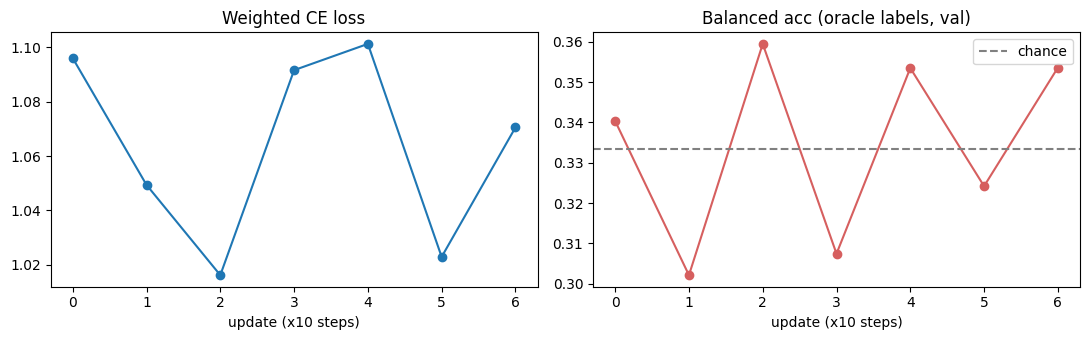

Note: per-frame balanced accuracy is bounded by spike-coding noise; closed-loop reward
(next cell) is the behaviorally meaningful metric.


In [43]:
# Section 7.1 - Supervised surrogate-gradient training through the connectome
def balanced_acc(pred, y):
    accs = [float((pred[y == c] == c).float().mean()) for c in y.unique()]
    return float(np.mean(accs))

xs_, ys_ = oracle_batch(n_env=64, T=30, seed=7)
cnt = torch.bincount(torch.cat([ys_.reshape(-1), torch.tensor([0, 2, 3], device=ys_.device)]),
                     minlength=7).float()
w_cls = torch.where(cnt > 0, cnt.sum() / (7 * cnt.clamp_min(1)), torch.zeros(7, device=DEVICE))
print("oracle label distribution:", cnt.cpu().numpy().astype(int).tolist())

# Garantir que o tensor A não carregue histórico de gradiente de edge_scale durante o BPTT
with torch.no_grad():
    model.edge_scale.requires_grad_(False)
    model.refresh_A()

H = T_STEPS // 2                       # score settled second half of each window
groups = [{"params": [model.W_out], "lr": 1e-2},
          {"params": [model.W_in, model.b_in, model.gain, model.v_th], "lr": 5e-3}]
opt = torch.optim.Adam(groups)
xva, yva = oracle_batch(n_env=32, T=30, seed=99)

hist = {"loss": [], "balacc_va": []}
t0 = time.time()
for step in range(TRAIN_STEPS):
    # Geramos um novo lote a cada passo para evitar reutilização de dados
    xtr, ytr = oracle_batch(n_env=min(BATCH, 32), T=T_STEPS, seed=1000 + step)

    opt.zero_grad()
    out, _ = model(xtr)
    loss = F.cross_entropy(out[H:].reshape(-1, N_ACTIONS), ytr[H:].reshape(-1), weight=w_cls)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()
    if step % 10 == 0 or step == TRAIN_STEPS - 1:
        with torch.no_grad():
            outv, _ = model(xva)
            bva = balanced_acc(outv[H:].argmax(-1).reshape(-1), yva[H:].reshape(-1))
        hist["loss"].append(float(loss.detach()))
        hist["balacc_va"].append(bva)
        print(f"  step {step:4d}: loss={float(loss.detach()):.4f} balacc_va={bva:.3f}")
train_s = time.time() - t0

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(hist["loss"], "o-"); ax[0].set_title("Weighted CE loss"); ax[0].set_xlabel("update (x10 steps)")
ax[1].plot(hist["balacc_va"], "o-", color="#d65f5f"); ax[1].set_title("Balanced acc (oracle labels, val)")
ax[1].set_xlabel("update (x10 steps)"); ax[1].axhline(1/3, ls="--", c="0.5", label="chance")
ax[1].legend(); plt.tight_layout(); plt.show()

# Correção do atributo .get() para listas - substituído por hist["loss"][0]
record("surrogate_gradient_training", "PASS" if hist["loss"][-1] < 0.9 * hist["loss"][0] else "WARN",
       steps=TRAIN_STEPS, loss_start=round(hist["loss"][0], 4), loss_end=round(hist["loss"][-1], 4),
       balacc_end=round(hist["balacc_va"][-1], 3), seconds=round(train_s, 1))
print("Note: per-frame balanced accuracy is bounded by spike-coding noise; closed-loop reward")
print("(next cell) is the behaviorally meaningful metric.")

A saída de streaming foi truncada nas últimas 5000 linhas.
        [240, 240, 240],
        [240, 240, 240]]], dtype=uint8), array([[[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       ...,

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240, 240, 240],
        [240, 240, 240],
        ...,
        [240, 240, 240],
        [240, 240, 240],
        [240, 240, 240]],

       [[240, 240, 240],
        [240

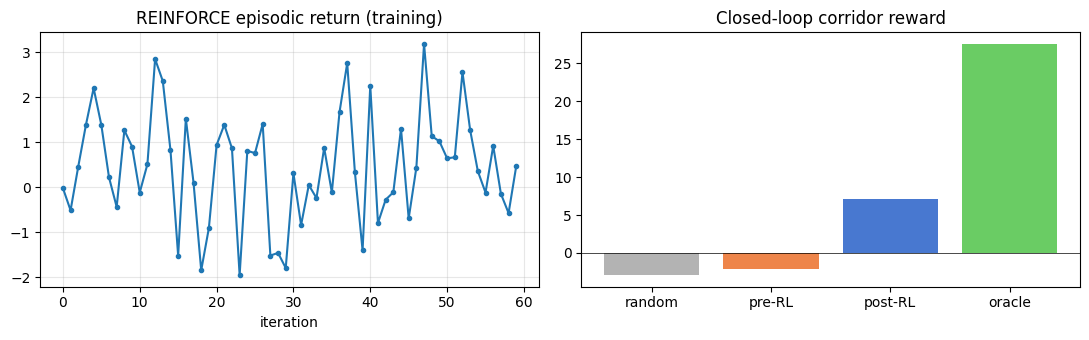

In [44]:
# Section 7.2 - Reward-modulated readout plasticity (three-factor REINFORCE, frozen connectome)
def reinforce_readout(mdl, n_iter=60, n_env=16, max_steps=250, gamma=0.99, lr=1e-2,
                      seed=0, ema=0.5, ent_coef=0.02, verbose_every=10):
    """Episodic REINFORCE on W_out only. Roll out no-grad (pass 1), then replay stored
    observations/actions and backprop through the readout frame-by-frame (pass 2).
    Deterministic dynamics (noise=0) make the replay exact; memory is O(chunk), not O(T*N)."""
    dev = mdl.W_out.device
    envs = [CorridorTask(seed=seed * 1000 + e) for e in range(n_env)]
    opt = torch.optim.Adam([mdl.W_out], lr=lr)
    history = []
    for it in range(n_iter):
        obs = [e.reset(start_x=5.0) for e in envs]
        carry, ema_l = None, None
        alive = np.ones(n_env, bool)
        mot_seq, act_seq, rew_seq, mask_seq = [], [], [], []
        with torch.no_grad():
            for s in range(max_steps):
                x = torch.tensor(np.stack(obs), dtype=torch.float32, device=dev).reshape(1, n_env, 8)
                out, st = mdl(x, hard=False, state=carry)
                carry = st["carry"]
                lg = out[0]
                logits = lg if ema_l is None else (1 - ema) * ema_l + ema * lg
                ema_l = logits
                dist = torch.distributions.Categorical(logits=logits)
                a = dist.sample()
                acts = a.tolist()
                mot_seq.append(st["mot"][0])
                mask_seq.append(alive.copy())
                r_s = np.zeros(n_env, dtype=np.float32)
                for b in range(n_env):
                    if alive[b]:
                        o, r, done = envs[b].step(acts[b])
                        obs[b] = o
                        r_s[b] = r
                        if done:
                            alive[b] = False
                act_seq.append(acts)
                rew_seq.append(r_s)
                if not alive.any():
                    break
        T = len(act_seq)
        R = np.zeros(n_env, dtype=np.float32)
        returns = np.zeros((T, n_env), dtype=np.float32)
        for t in reversed(range(T)):
            R = rew_seq[t] + gamma * R
            returns[t] = R
        adv = returns - returns.mean()
        adv = adv / (adv.std() + 1e-6)
        history.append(float(returns[0].mean()))

        mot_t = torch.stack(mot_seq)                                    # (T,B,M) detached
        act_t = torch.tensor(np.array(act_seq), dtype=torch.long, device=dev)
        adv_t = torch.tensor(adv, dtype=torch.float32, device=dev)
        mask_t = torch.tensor(np.stack(mask_seq), dtype=torch.float32, device=dev)
        ntok = float(mask_t.sum().clamp_min(1))
        opt.zero_grad()
        ema_l = None
        for t in range(T):
            lg = mot_t[t] @ mdl.W_out.T
            logits = lg if ema_l is None else (1 - ema) * ema_l.detach() + ema * lg
            ema_l = logits
            dist = torch.distributions.Categorical(logits=logits)
            lp = dist.log_prob(act_t[t])
            ent = dist.entropy()
            (-(((lp * adv_t[t] + ent_coef * ent) * mask_t[t]).sum()) / ntok).backward()
        torch.nn.utils.clip_grad_norm_([mdl.W_out], 5.0)
        opt.step()
        for gp in opt.param_groups:
            gp["lr"] = lr * (1.0 - (it + 1) / n_iter) + 1e-4
        if verbose_every and (it % verbose_every == 0 or it == n_iter - 1):
            print(f"  readout-RL iter {it:3d}: episodic_return={history[-1]:+.2f} steps={T}")
    return history

noise_backup, model.noise = model.noise, 0.0          # deterministic replay for pass 2
# Readout plasticity starts from naive synapses: reset W_out so RL measures reward-driven
# learning from scratch (the supervised phase above tested BPTT through the wiring instead).
with torch.no_grad():
    model.W_out.normal_(0.0, 0.1)

# Before RL - with video recording
print("Recording pre-RL behavior...")
cl_pre = run_closed_loop(model, policy="model", seed=5, n_episodes=8, record_video=HAS_CV2)
print("closed-loop BEFORE RL :", cl_pre)

# Training
t0 = time.time()
rl_hist = reinforce_readout(model, n_iter=RL_ITERS, n_env=RL_ENVS, seed=3)
rl_s = time.time() - t0
model.noise = noise_backup

# After RL - with video recording
print("Recording post-RL behavior...")
cl_post = run_closed_loop(model, policy="model", seed=5, n_episodes=8, record_video=HAS_CV2)
cl_rand = run_closed_loop(model, policy="random", seed=5, n_episodes=8)
cl_orac = run_closed_loop(model, policy="oracle", seed=5, n_episodes=8)
print("closed-loop AFTER RL   :", cl_post)
print("random policy          :", cl_rand)
print("oracle policy          :", cl_orac)

# Save videos if available
if HAS_CV2 and "video_frames" in cl_pre:
    save_video(cl_pre["video_frames"], "pre_rl_corridor.mp4", fps=15)
    print("Saved pre-RL video: pre_rl_corridor.mp4")
if HAS_CV2 and "video_frames" in cl_post:
    save_video(cl_post["video_frames"], "post_rl_corridor.mp4", fps=15)
    print("Saved post-RL video: post_rl_corridor.mp4")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(rl_hist, "o-", ms=3); ax[0].set_title("REINFORCE episodic return (training)")
ax[0].set_xlabel("iteration"); ax[0].grid(alpha=0.3)
names = ["random", "pre-RL", "post-RL", "oracle"]
ax[1].bar(names, [cl_rand["reward"], cl_pre["reward"], cl_post["reward"], cl_orac["reward"]],
          color=["0.7", "#ee854a", "#4878d0", "#6acc64"])
ax[1].set_title("Closed-loop corridor reward"); ax[1].axhline(0, c="k", lw=0.5)
plt.tight_layout(); plt.show()

ok = (cl_post["reward"] > max(cl_pre["reward"], cl_rand["reward"])) and cl_post["success"] > 0
record("readout_rl_closed_loop", "PASS" if ok else "WARN",
       reward_pre=cl_pre["reward"], reward_post=cl_post["reward"],
       reward_random=cl_rand["reward"], reward_oracle=cl_orac["reward"],
       success_post=cl_post["success"], survival_post=cl_post["survival"],
       rl_iters=RL_ITERS, seconds=round(rl_s, 1))

## Section 8 - Neuromodulated STDP (weight plasticity on the wiring itself)

The readout RL above keeps the connectome frozen. Here we plasticize the **synaptic weights of the
wiring diagram**, implementing the project's three-factor rule from `config/config.yaml`
(`metalearning.plasticity`): pre/post coincidence **eligibility traces** (pair STDP, tau = 20 ms)
accumulated along an episode, then gated by a **dopamine** scalar (reward) - positive DA
potentiates co-active synapses, punishment (negative DA) depresses them. A homeostatic threshold
adjustment (target ~10 Hz, `plasticity.target_rate`) keeps the network in range.


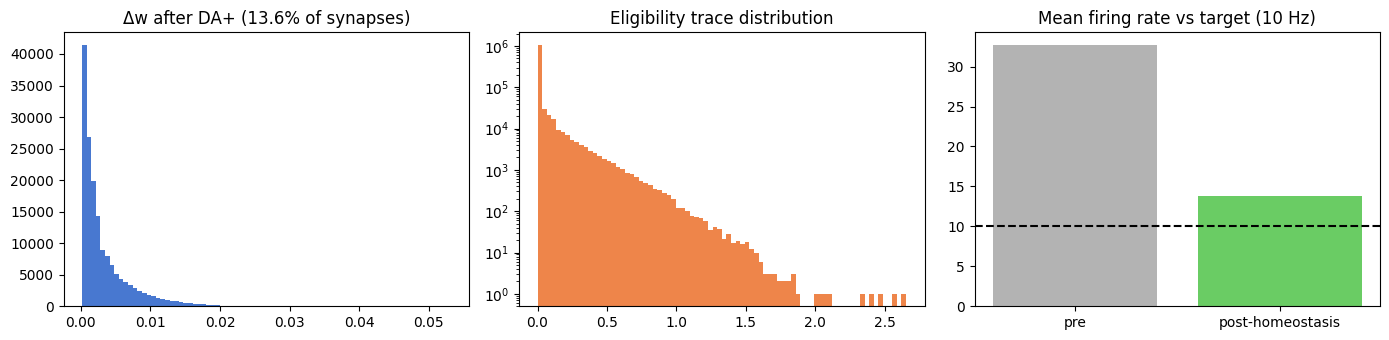

In [45]:
# Section 8.1 - Three-factor STDP episode: eligibility -> dopamine gating -> homeostasis
t0 = time.time()
xtr_s, _ = oracle_batch(n_env=8, T=60, seed=55)
noise_backup, model.noise = model.noise, 0.0
with torch.no_grad():
    _, st0 = model(xtr_s, hard=True)
    rate_pre = float(st0["rates"].mean()) * 1000
    w_before = model.edge_scale.clone()

    _, stp = model(xtr_s, hard=True, stdp_tau=20.0)
    elig = stp["elig"]
    DA = +1.0                                        # dopamine burst (rewarding episode)
    model.edge_scale.add_(elig * 0.02 * DA).clamp_(0.2, 3.0)
    model.refresh_A()
    dw_pos = model.edge_scale - w_before

    _, stn = model(xtr_s, hard=True, stdp_tau=20.0)
    DA = -1.0                                        # punishment dip
    model.edge_scale.add_(stn["elig"] * 0.02 * DA).clamp_(0.2, 3.0)
    model.refresh_A()
    dw_net = model.edge_scale - w_before

    _, st1 = model(xtr_s, hard=True)
    rate_mid = float(st1["rates"].mean()) * 1000

    # homeostatic threshold control toward target_rate = 10 Hz (config)
    for _ in range(5):
        model.v_th.data += 0.05 * (rate_mid - 10.0) / 10.0
        _, sth = model(xtr_s, hard=True)
        rate_mid = float(sth["rates"].mean()) * 1000
    rate_post = rate_mid
model.noise = noise_backup
stdp_s = time.time() - t0

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
dw_s = dw_pos.cpu().numpy()
ax[0].hist(dw_s[np.abs(dw_s) > 1e-8], bins=80, color="#4878d0")
ax[0].set_title(f"Δw after DA+ ({float((dw_s!=0).mean()):.1%} of synapses)")
ax[1].hist(elig.cpu().numpy(), bins=80, range=(0, max(float(elig.max()), 1e-6)), color="#ee854a")
ax[1].set_yscale("log"); ax[1].set_title("Eligibility trace distribution")
ax[2].bar(["pre", "post-homeostasis"], [rate_pre, rate_post], color=["0.7", "#6acc64"])
ax[2].axhline(10, ls="--", c="k"); ax[2].set_title("Mean firing rate vs target (10 Hz)")
plt.tight_layout(); plt.show()

changed = float((dw_pos.abs() > 1e-8).float().mean())
bounded = bool(model.edge_scale.min() >= 0.2 and model.edge_scale.max() <= 3.0)
record("neuromodulated_stdp", "PASS" if changed > 0.01 and bounded else "FAIL",
       synapses_changed=round(changed, 4), mean_abs_dw=round(float(dw_pos.abs().mean()), 5),
       rate_pre_hz=round(rate_pre, 2), rate_post_hz=round(rate_post, 2),
       bounded=bounded, seconds=round(stdp_s, 1))


## Section 9 - Brian2 spiking simulation (conductance-free LIF, real wiring)

Independent check with the repo's chosen simulator (**Brian2**, `config.yaml simulator.backend`):
a slice of up to `BRIAN2_MAX` neurons from the same sub-brain, simulated as a spiking LIF network
with 1 ms delays, Poisson sensory drive, recurrent weights auto-tuned into a 5 Hz regime.
This cell is written from scratch because the repo's `DrosophilaSNN` cannot run as-is (finding F5).
Uses the cython codegen target on Colab (gcc available); the numpy target elsewhere.


In [46]:
# Section 9.1 - Brian2 network on a connectome slice
if RUN_BRIAN2:
    try:
        # Ensure cython is available on Colab for codegen target
        if IN_COLAB:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "cython"], check=False)

        t0 = time.time()
        import brian2
        from brian2 import (NeuronGroup, Synapses, PoissonGroup, SpikeMonitor, Network,
                            ms, mV, second, Hz, prefs, defaultclock)
        # Use cython on Colab (gcc available), numpy elsewhere
        brian2.prefs.codegen.target = "cython" if IN_COLAB else "numpy"
        brian2.prefs.logging.console_log_level = "WARNING"
        defaultclock.dt = 0.2 * ms

        b_target = min(BRIAN2_MAX, N)
        sub_b, pb_, qb_, web_ = build_subgraph(fc_ann, fc_p, fc_q, fc_we, b_target, seed=SEED + 1)
        bt_b = make_brain_tensors(sub_b, pb_, qb_, web_)
        nb = bt_b["n"]
        w_log = np.log1p(web_.astype(np.float64))
        indeg_sq = np.zeros(nb); np.add.at(indeg_sq, qb_, w_log ** 2)
        norm = np.sqrt(np.maximum(indeg_sq, 1e-9))
        base_w = (w_log / norm[qb_]) * bt_b["e_sign"]          # signed, balanced

        eqs = """
        dv/dt = (EL + I_drive - v)/tau_m : volt (unless refractory)
        I_drive : volt
        tau_m : second
        EL : volt
        VT : volt
        """
        G = NeuronGroup(nb, eqs, threshold="v > VT", reset="v = EL", refractory=2 * ms, method="exact")
        G.EL = -65 * mV
        G.VT = -50 * mV
        G.tau_m = "(15 + 10*rand())*ms"
        G.I_drive = "(10 + 8*rand())*mV"
        G.v = "EL + 5*mV*rand()"

        S = Synapses(G, G, "w : volt", on_pre="v_post += w", delay=1 * ms)
        S.connect(i=pb_.astype(np.int64), j=qb_.astype(np.int64))

        sens_cap = bt_b["sens_idx"][:3000]
        P = PoissonGroup(len(sens_cap), rates=120 * Hz)
        SP = Synapses(P, G, on_pre="v_post += 5.0*mV", delay=1 * ms)
        SP.connect(i=np.arange(len(sens_cap)), j=sens_cap.astype(np.int64))

        mon = SpikeMonitor(G)
        net = Network(G, S, P, SP, mon)
        net.store("init")
        build_s = time.time() - t0

        is_sens_b = np.zeros(nb, bool); is_sens_b[bt_b["sens_idx"]] = True
        best = None
        for scale in [0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]:
            net.restore("init")
            S.w = base_w * scale * mV
            net.run(50 * ms)
            spk = mon.i[:]
            down_rate = ((~is_sens_b[spk]).sum()) / (0.05 * max(nb - is_sens_b.sum(), 1))
            if best is None or abs(math.log(max(down_rate, 0.1) / 5.0)) < abs(math.log(max(best[1], 0.1) / 5.0)):
                best = (scale, down_rate)
        net.restore("init")
        S.w = base_w * best[0] * mV
        mon2 = SpikeMonitor(G)
        net.add(mon2)
        t1 = time.time()
        net.run(200 * ms)
        wall = time.time() - t1
        si, st_ = mon2.i[:], mon2.t[:] / ms
        rate_hz = len(si) / (0.2 * nb)
        rtf = 0.2 / max(wall, 1e-9)

        fig, ax = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
        sel = si < 300
        ax[0].scatter(st_[sel], si[sel], s=0.5, c="k")
        ax[0].set_ylabel("neuron #"); ax[0].set_title(f"Brian2 raster (first 300 of {nb:,} neurons, {best[0]}x weight scale)")
        bins = np.arange(0, 200, 2)
        cnts, _ = np.histogram(st_, bins=bins)
        ax[1].plot(bins[:-1], cnts / (nb * 0.002), lw=1, color="#4878d0")
        ax[1].set_xlabel("time (ms)"); ax[1].set_ylabel("population rate (Hz)")
        plt.tight_layout(); plt.show()

        record("brian2_spiking_network", "PASS" if len(si) > 0 else "FAIL",
               neurons=nb, synapses=int(len(pb_)), mean_rate_hz=round(rate_hz, 2),
               spikes=int(len(si)), real_time_factor=round(rtf, 3),
               build_seconds=round(build_s, 1), sim_seconds=round(wall, 1),
               codegen=brian2.prefs.codegen.target)
    except Exception as e:
        record("brian2_spiking_network", "FAIL", error=f"{type(e).__name__}: {str(e)[:200]}")
else:
    record("brian2_spiking_network", "SKIP", reason="RUN_BRIAN2=False")

## Section 11 - Test report & artifacts


In [48]:
import os, json, time, shutil
from pathlib import Path
import pandas as pd
import torch

# Section 11.1 - Full test report + saved artifacts
report = pd.DataFrame(RESULTS)
order = {"PASS": 0, "WARN": 1, "KNOWN_ISSUE": 2, "FAIL": 3, "SKIP": 4}
report["_o"] = report["status"].map(order).fillna(9)
report = report.sort_values(["_o", "test"]).drop(columns="_o").dropna(axis=1, how="all")
pd.set_option("display.max_colwidth", 90)
print(report.to_string(index=False))

n_pass = int((report["status"] == "PASS").sum())
n_issue = int((report["status"] == "KNOWN_ISSUE").sum())
n_fail = int((report["status"] == "FAIL").sum())
total_min = (time.time() - T_START) / 60
print(f"\n{n_pass} PASS / {n_issue} KNOWN_ISSUE / {n_fail} FAIL / "
      f"{int((report['status']=='SKIP').sum())} SKIP  -  total runtime {total_min:.1f} min")

# artifacts - Correção segura do DATA_OK
is_data_ok = globals().get("DATA_OK", False)
art_dir = globals().get("DATA_DIR", Path("/content/data")) if (is_data_ok or not IN_COLAB) else Path("/content/data")
art_dir.mkdir(parents=True, exist_ok=True)
res_path = art_dir / "results_colab_brain_test.json"
with open(res_path, "w") as f:
    json.dump({"results": RESULTS,
               "scale": SCALE, "neurons": N, "edges": E,
               "calibration": {k: float(v) for k, v in cal.items()},
               "device": str(DEVICE), "runtime_minutes": round(total_min, 2)}, f, indent=2, default=str)
print("saved:", res_path)

ckpt = {k: v.detach().cpu() for k, v in model.state_dict().items()
        if k in ("W_in", "b_in", "gain", "v_th", "W_out", "input_gain", "syn_scale",
                 "inh_scale", "edge_scale")}
ckpt_path = art_dir / f"brain_{SCALE}_{N}.pt"
torch.save(ckpt, ckpt_path)
print(f"saved checkpoint ({ckpt_path.stat().st_size/1e6:.1f} MB):", ckpt_path)

if DRIVE_CACHE is not None:
    try:
        shutil.copy(res_path, DRIVE_CACHE / res_path.name)
        shutil.copy(ckpt_path, DRIVE_CACHE / ckpt_path.name)
        print("copied artifacts to Drive cache")
    except Exception as e:
        print("Drive copy failed:", e)

if IN_COLAB:
    try:
        from google.colab import files
        files.download(str(res_path))
    except Exception:
        pass

                       test status scale  neurons     edges  sensory  motor  modulatory  mean_degree  giant_component_frac  weak_components  seconds  median_degree  max_out_degree  pct_isolated  synapses  params_M  hard_fwd_ms_per_step  bptt_ms_per_step  peak_vram_MB  mean_rate_hz  sensory_probe_acc  motor_probe_acc  all_neurons_acc  obs_sanity_acc  steps  loss_start  loss_end  balacc_end  reward_pre  reward_post  reward_random  reward_oracle  success_post  survival_post  rl_iters  synapses_changed  mean_abs_dw  rate_pre_hz  rate_post_hz bounded                                         error
            graph_analytics   PASS   NaN      NaN       NaN      NaN    NaN         NaN          NaN                   NaN              NaN      NaN           24.0           914.0           0.0       NaN       NaN                   NaN               NaN           NaN           NaN                NaN              NaN              NaN             NaN    NaN         NaN       NaN         NaN         Na

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>